# TIL github testing

In [2]:
def get_objective_power(slide: openslide.OpenSlide) -> float:
    """
    從 OpenSlide 物件中獲取物鏡倍率。
    優先嘗試讀取 'openslide.objective-power'。
    如果失敗，則嘗試從 'openslide.mpp-x' 計算。
    如果兩者都失敗，返回一個預設值（例如 40.0）並顯示警告。
    """
    try:
        # 優先嘗試直接讀取屬性
        objective = float(slide.properties[openslide.PROPERTY_NAME_OBJECTIVE_POWER])
        return objective
    except (KeyError, ValueError):
        # 如果 'objective-power' 不存在或格式不對，嘗試從 MPP 計算
        print("Warning: 'openslide.objective-power' not found. Trying to calculate from MPP.")
        try:
            mpp_x = float(slide.properties[openslide.PROPERTY_NAME_MPP_X])
            # 經驗公式： objective ≈ 10 / mpp
            # 40x ≈ 0.25 mpp -> 10 / 0.25 = 40
            # 20x ≈ 0.50 mpp -> 10 / 0.50 = 20
            objective = 10 / mpp_x
            return objective
        except (KeyError, ValueError, ZeroDivisionError):
            # 3. 如果連 MPP 都無法獲取或無效，拋出一個明確的錯誤
            error_message = (
                "Could not determine objective power. Both 'openslide.objective-power' and "
                "'openslide.mpp-x' are missing or invalid in the slide properties."
            )
            # 使用 raise 將錯誤拋出，中止函式執行
            raise ValueError(error_message) from e

In [8]:
import openslide
from openslide.deepzoom import DeepZoomGenerator
from matplotlib import pyplot as plt

directory_path = "./WSI_example/FMT0411_20210805_003936_1_20210805_084813.tiff"
#directory_path = "./WSI_example/TCGA-44-6145-01Z-00-DX1.svs"
PATCH_SIZE = 150

try:
    slide = openslide.OpenSlide(directory_path)
except Exception as e:
    print(f"Error opening slide at {directory_path}: {str(e)}")

objective = get_objective_power(slide)
tiles = DeepZoomGenerator(slide, tile_size=PATCH_SIZE, overlap=0, limit_bounds=False)
level = tiles.level_count - 1 if objective < 40.0 else tiles.level_count - 2
cols, rows = tiles.level_tiles[level]

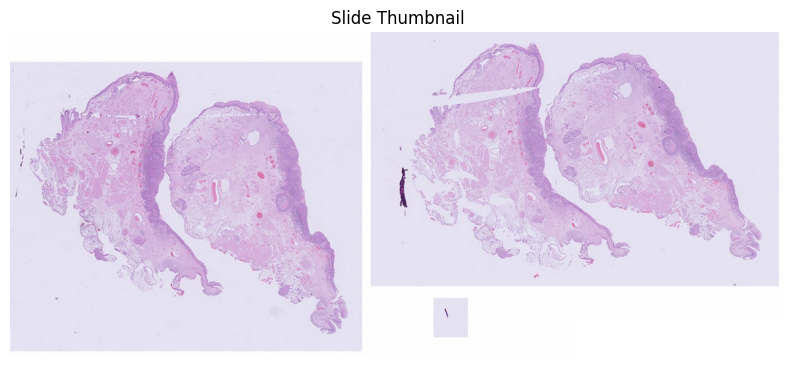

In [9]:
thumbnail = slide.get_thumbnail((1024, 1024))

# 使用 matplotlib 顯示影像
plt.figure(figsize=(10, 10)) # 可以調整顯示出來的圖片大小
plt.imshow(thumbnail)
plt.title('Slide Thumbnail')
plt.axis('off') # 關閉座標軸
plt.show()

In [10]:
level_to_check = 0
if level_to_check < slide.level_count:
    level_dims = slide.level_dimensions[level_to_check]
    print(f"Level {level_to_check} 的大小 (寬, 高): {level_dims}")
    print(f"寬度: {level_dims[0]} 像素")
    print(f"高度: {level_dims[1]} 像素")

Level 0 的大小 (寬, 高): (179712, 75264)
寬度: 179712 像素
高度: 75264 像素


In [41]:
col, row = int(cols/6), int(rows/2)
col, row

(108, 160)

In [42]:
import numpy as np
import tifffile as tiff
from normalize_HnE import norm_HnE

In [43]:
tile_name = f"{col}_{row}"

temp_tile = tiles.get_tile(level, (col, row))
temp_tile_RGB = temp_tile.convert('RGB')
temp_tile_np = np.array(temp_tile_RGB)
if temp_tile_np.mean() < 230 and temp_tile_np.std() > 15:
    # Log processing event 
    norm_img, _, _ = norm_HnE(temp_tile_np, Io=240, alpha=1, beta=0.15)
    #tiff.imsave(os.path.join(file_name, f"{tile_name}_{label[:23]}_norm.tif"), norm_img)
    #logging.info(f"Processing tile number: {tile_name}")
else:
    print('Out')

In [44]:
norm_img.shape

(150, 150, 3)

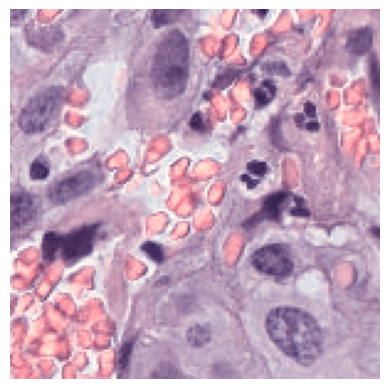

In [45]:
import matplotlib.pyplot as plt
plt.imshow(norm_img)      # correct for H×W×C images
plt.axis('off')           # optional: hide axes
plt.show()

# In-house testing set

In [5]:
output_folder = "csv_results_v3"

In [6]:
!python InceptionResNetV2_testing.py \
    --test_dir "Train_new2/test" \
    --model_dir "." \
    --output_file "test_results.json" \
    --csv_output {output_folder} \
    --csv_prefix "test_test"

2025-07-16 03:40:59.581992: I tensorflow/core/platform/cpu_feature_guard.cc:194] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE3 SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
InceptionResNetV2 Testing Script
測試資料夾: Train_new2/test
模型目錄: .
Folds數量: 10

▶  載入測試資料 ...
  ➜ 測試集 18216 張
  ➜ 類別對應: ['A_positive', 'B_negative', 'C_other']
  ➜ 類別分布:
    A_positive: 4031 張
    B_negative: 7974 張
    C_other: 6211 張

▶  載入 10 個fold模型並進行預測 ...

======== Individual Fold Results ========

--- Fold 01 ---
Accuracy: 0.9805
Precision: 0.9805
Recall: 0.9805
F1-Score: 0.9805
Kappa: 0.9696
AUC: 0.9991

--- Fold 02 ---
Accuracy: 0.9811
Precision: 0.9811
Recall: 0.9811
F1-Score: 0.9811
Kappa: 0.9706
AUC: 0.9990

--- Fold 03 ---
Accuracy: 0.9814
Precision: 0.9814
Recall: 0.9814
F1-Score: 0.9814
Kappa: 0.9711
AUC: 0.9990

--- Fold 0

# RNMU-BRCA

In [7]:
!python InceptionResNetV2_testing.py \
    --test_dir "Testset/RUMC-BRCA" \
    --model_dir "." \
    --output_file "brca_results.json" \
    --csv_output {output_folder} \
    --csv_prefix "brca_test"

2025-07-16 03:45:25.010527: I tensorflow/core/platform/cpu_feature_guard.cc:194] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE3 SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
InceptionResNetV2 Testing Script
測試資料夾: Testset/RUMC-BRCA
模型目錄: .
Folds數量: 10

▶  載入測試資料 ...
  ➜ 測試集 3000 張
  ➜ 類別對應: ['A_positive', 'B_negative', 'C_other']
  ➜ 類別分布:
    A_positive: 162 張
    B_negative: 1219 張
    C_other: 1619 張

▶  載入 10 個fold模型並進行預測 ...

======== Individual Fold Results ========

--- Fold 01 ---
Accuracy: 0.9473
Precision: 0.9501
Recall: 0.9473
F1-Score: 0.9479
Kappa: 0.9030
AUC: 0.9933

--- Fold 02 ---
Accuracy: 0.9527
Precision: 0.9545
Recall: 0.9527
F1-Score: 0.9530
Kappa: 0.9127
AUC: 0.9936

--- Fold 03 ---
Accuracy: 0.9530
Precision: 0.9555
Recall: 0.9530
F1-Score: 0.9534
Kappa: 0.9134
AUC: 0.9937

--- Fold 0

# CPTAC_LUAD

In [8]:
!python InceptionResNetV2_testing.py \
    --test_dir "Testset/CPTAC_LUAD" \
    --model_dir "." \
    --output_file "luad_results.json" \
    --csv_output {output_folder} \
    --csv_prefix "luad_test"

2025-07-16 03:46:57.422466: I tensorflow/core/platform/cpu_feature_guard.cc:194] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE3 SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
InceptionResNetV2 Testing Script
測試資料夾: Testset/CPTAC_LUAD
模型目錄: .
Folds數量: 10

▶  載入測試資料 ...
  ➜ 測試集 3000 張
  ➜ 類別對應: ['A_positive', 'B_negative', 'C_other']
  ➜ 類別分布:
    A_positive: 224 張
    B_negative: 1357 張
    C_other: 1419 張

▶  載入 10 個fold模型並進行預測 ...

======== Individual Fold Results ========

--- Fold 01 ---
Accuracy: 0.9353
Precision: 0.9361
Recall: 0.9353
F1-Score: 0.9353
Kappa: 0.8857
AUC: 0.9904

--- Fold 02 ---
Accuracy: 0.9323
Precision: 0.9331
Recall: 0.9323
F1-Score: 0.9323
Kappa: 0.8804
AUC: 0.9902

--- Fold 03 ---
Accuracy: 0.9393
Precision: 0.9403
Recall: 0.9393
F1-Score: 0.9394
Kappa: 0.8929
AUC: 0.9903

--- Fold 

# CPTAC_LUSC

In [9]:
!python InceptionResNetV2_testing.py \
    --test_dir "Testset/CPTAC_LUSC" \
    --model_dir "." \
    --output_file "lusc_results.json" \
    --csv_output {output_folder} \
    --csv_prefix "lusc_test"

2025-07-16 03:48:29.369083: I tensorflow/core/platform/cpu_feature_guard.cc:194] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE3 SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
InceptionResNetV2 Testing Script
測試資料夾: Testset/CPTAC_LUSC
模型目錄: .
Folds數量: 10

▶  載入測試資料 ...
  ➜ 測試集 3000 張
  ➜ 類別對應: ['A_positive', 'B_negative', 'C_other']
  ➜ 類別分布:
    A_positive: 291 張
    B_negative: 1769 張
    C_other: 940 張

▶  載入 10 個fold模型並進行預測 ...

======== Individual Fold Results ========

--- Fold 01 ---
Accuracy: 0.9583
Precision: 0.9599
Recall: 0.9583
F1-Score: 0.9587
Kappa: 0.9246
AUC: 0.9956

--- Fold 02 ---
Accuracy: 0.9557
Precision: 0.9572
Recall: 0.9557
F1-Score: 0.9560
Kappa: 0.9197
AUC: 0.9948

--- Fold 03 ---
Accuracy: 0.9573
Precision: 0.9594
Recall: 0.9573
F1-Score: 0.9577
Kappa: 0.9229
AUC: 0.9944

--- Fold 0

## Tar extracting

In [1]:
import glob
import os

import tarfile
from concurrent.futures import ProcessPoolExecutor

base_folder = 'Overlap0_in151to150' #'Overlap_in896_invasion'

dirfile = os.path.join('./', base_folder, '*.tar')
out_path = os.path.join('./', base_folder)

def tar_extract(tar_path):
    tar = tarfile.open(tar_path, 'r')
    file_names = tar.getnames()
    for file_name in file_names:
        tar.extract(file_name, out_path)
    image_name = tar_path.split("/")[-1].split(".")[0]
    print(f"{image_name = }")
    tar.close()
    #Reomve tar filoder
    os.remove(tar_path)

f_all = glob.iglob(dirfile)
with ProcessPoolExecutor() as executor: #Process
    results = executor.map(tar_extract, f_all)

print("Finish extract")

image_name = 'TCGA-44-6145-01Z-00-DX1'
Finish extract


In [3]:
print("1. 基本推論 (使用預設參數)")
print("python inference_InceptionResNetV2.py")
print()

print("2. 指定模型檔案和輸入資料夾")
print("python inference_InceptionResNetV2.py --model-path best_InceptionResNetV2_model.h5 --input-dir ./Overlap0_in151to150")
print()

print("3. 指定輸出資料夾和批次大小")
print("python inference_InceptionResNetV2.py --output-dir ./my_results --batch-size 16")
print()

print("4. 完整參數範例")
print("python inference_InceptionResNetV2.py --model-path best_InceptionResNetV2_model.h5 --input-dir ./Overlap0_in151to150 --output-dir ./inference_results --batch-size 32")
print()

# 顯示所有可用的參數
print("=== 可用參數說明 ===")
print("--model-path: 模型檔案路徑 (預設: best_InceptionResNetV2_model.h5)")
print("--input-dir: 輸入資料夾路徑 (預設: ./Overlap0_in151to150)")
print("--output-dir: 輸出結果資料夾路徑 (預設: ./inference_results)")
print("--batch-size: 推論的批次大小 (預設: 32)")
print()

print("=== 輸出檔案格式 ===")
print("程式會在輸出資料夾中為每個影像創建一個CSV檔案")
print("CSV檔案包含以下欄位:")
print("- Image: 影像名稱")
print("- x, y: 座標位置")
print("- prediction: 預測類別")
print("- confidence: 預測信心度")
print("- Truth: 真實標籤 (推論時為空)")
print("- [類別名稱]_conf: 每個類別的信心度")
print("- Not_Normal_conf: 非正常類別的信心度")
print()

print("=== 注意事項 ===")
print("1. 請確保模型檔案存在且與訓練時的架構相同")
print("2. 請根據實際訓練時的類別順序調整 inference_InceptionResNetV2.py 中的 class_names")
print("3. 輸入資料夾應包含 PNG 影像檔案")
print("4. 影像檔案名稱格式應為: X;Y.png (例如: 002114;058588.png)")
print()

1. 基本推論 (使用預設參數)
python inference_InceptionResNetV2.py

2. 指定模型檔案和輸入資料夾
python inference_InceptionResNetV2.py --model-path best_InceptionResNetV2_model.h5 --input-dir ./Overlap0_in151to150

3. 指定輸出資料夾和批次大小
python inference_InceptionResNetV2.py --output-dir ./my_results --batch-size 16

4. 完整參數範例
python inference_InceptionResNetV2.py --model-path best_InceptionResNetV2_model.h5 --input-dir ./Overlap0_in151to150 --output-dir ./inference_results --batch-size 32

=== 可用參數說明 ===
--model-path: 模型檔案路徑 (預設: best_InceptionResNetV2_model.h5)
--input-dir: 輸入資料夾路徑 (預設: ./Overlap0_in151to150)
--output-dir: 輸出結果資料夾路徑 (預設: ./inference_results)
--batch-size: 推論的批次大小 (預設: 32)

=== 輸出檔案格式 ===
程式會在輸出資料夾中為每個影像創建一個CSV檔案
CSV檔案包含以下欄位:
- Image: 影像名稱
- x, y: 座標位置
- prediction: 預測類別
- confidence: 預測信心度
- Truth: 真實標籤 (推論時為空)
- [類別名稱]_conf: 每個類別的信心度
- Not_Normal_conf: 非正常類別的信心度

=== 注意事項 ===
1. 請確保模型檔案存在且與訓練時的架構相同
2. 請根據實際訓練時的類別順序調整 inference_InceptionResNetV2.py 中的 class_names
3. 輸入資料夾應包含 PNG 影像檔案
4. 影像檔案名稱格式應為: